# Hierarchikus Klaszterezés - Bank Marketing Dataset
## Agglomeratív (Ward módszer) - Age és Balance

### Célkitűzések:
- Hierarchikus (Agglomeratív) klaszterezés
- 2 változó: **age** (életkor) és **balance** (egyenleg)
- Ward linkage módszer
- Klaszterszám tesztelése: k=2-től k=8-ig
- Dendrogram vizualizáció vágási pontokkal
- Validációs metrikák és optimális k kiválasztása
- **Exportálás: exports_hacluster/ mappába**

## 1. Könyvtárak importálása

In [ ]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Scipy hierarchikus klaszterezéshez
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Könyvtárak sikeresen betöltve!")

✓ Könyvtárak sikeresen betöltve!
✓ exports_hacluster mappa ellenőrizve/létrehozva!


## 2. Adatok betöltése és előkészítése

In [2]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor (age, balance):")
print(df[['age', 'balance']].head())
print("\nStatisztikák:")
print(df[['age', 'balance']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor (age, balance):
   age  balance
0   58     2143
1   44       29
2   33        2
3   47     1506
4   33        1

Statisztikák:
                age        balance
count  45211.000000   45211.000000
mean      40.936210    1362.272058
std       10.618762    3044.765829
min       18.000000   -8019.000000
25%       33.000000      72.000000
50%       39.000000     448.000000
75%       48.000000    1428.000000
max       95.000000  102127.000000


In [3]:
# Feature Selection: age és balance
features = ['age', 'balance']
X = df[features].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")

# Normalizálás: StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  data_scaled alakja: {data_scaled.shape}")
print(f"  Átlag: {data_scaled.mean(axis=0)}")
print(f"  Szórás: {data_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['age', 'balance']
Adatpontok száma: 45,211

✓ Adatok normalizálva (StandardScaler)!
  data_scaled alakja: (45211, 2)
  Átlag: [2.1122502e-16 1.7602085e-17]
  Szórás: [1. 1.]


## 3. Hierarchikus Klaszterezés - Linkage Számítás (Ward)

In [4]:
# Hierarchikus klaszterezés - Ward linkage
print("="*70)
print("HIERARCHIKUS KLASZTEREZÉS - LINKAGE SZÁMÍTÁS")
print("="*70)
print("Linkage módszer: Ward")
print(f"Adatpontok száma: {len(data_scaled):,}")
print("\nLinkage számítása (ez eltarthat néhány percig nagy adatnál)...")

# Ward linkage számítása
Z = linkage(data_scaled, method='ward')

print("\n✓ Linkage mátrix kiszámítva!")
print(f"  Z alakja: {Z.shape}")
print(f"  Z oszlopai: [cluster1, cluster2, távolság, elemszám]")
print("\nElső 5 összevonás:")
print(pd.DataFrame(Z[:5], columns=['Cluster_1', 'Cluster_2', 'Distance', 'Size']))

HIERARCHIKUS KLASZTEREZÉS - LINKAGE SZÁMÍTÁS
Linkage módszer: Ward
Adatpontok száma: 45,211

Linkage számítása (ez eltarthat néhány percig nagy adatnál)...

✓ Linkage mátrix kiszámítva!
  Z alakja: (45210, 4)
  Z oszlopai: [cluster1, cluster2, távolság, elemszám]

Első 5 összevonás:
   Cluster_1  Cluster_2  Distance  Size
0     7287.0    12494.0       0.0   2.0
1    39479.0    45211.0       0.0   3.0
2     7960.0    13152.0       0.0   2.0
3    15877.0    45213.0       0.0   3.0
4    16329.0    45214.0       0.0   4.0


## 4. Dendrogram Vizualizáció

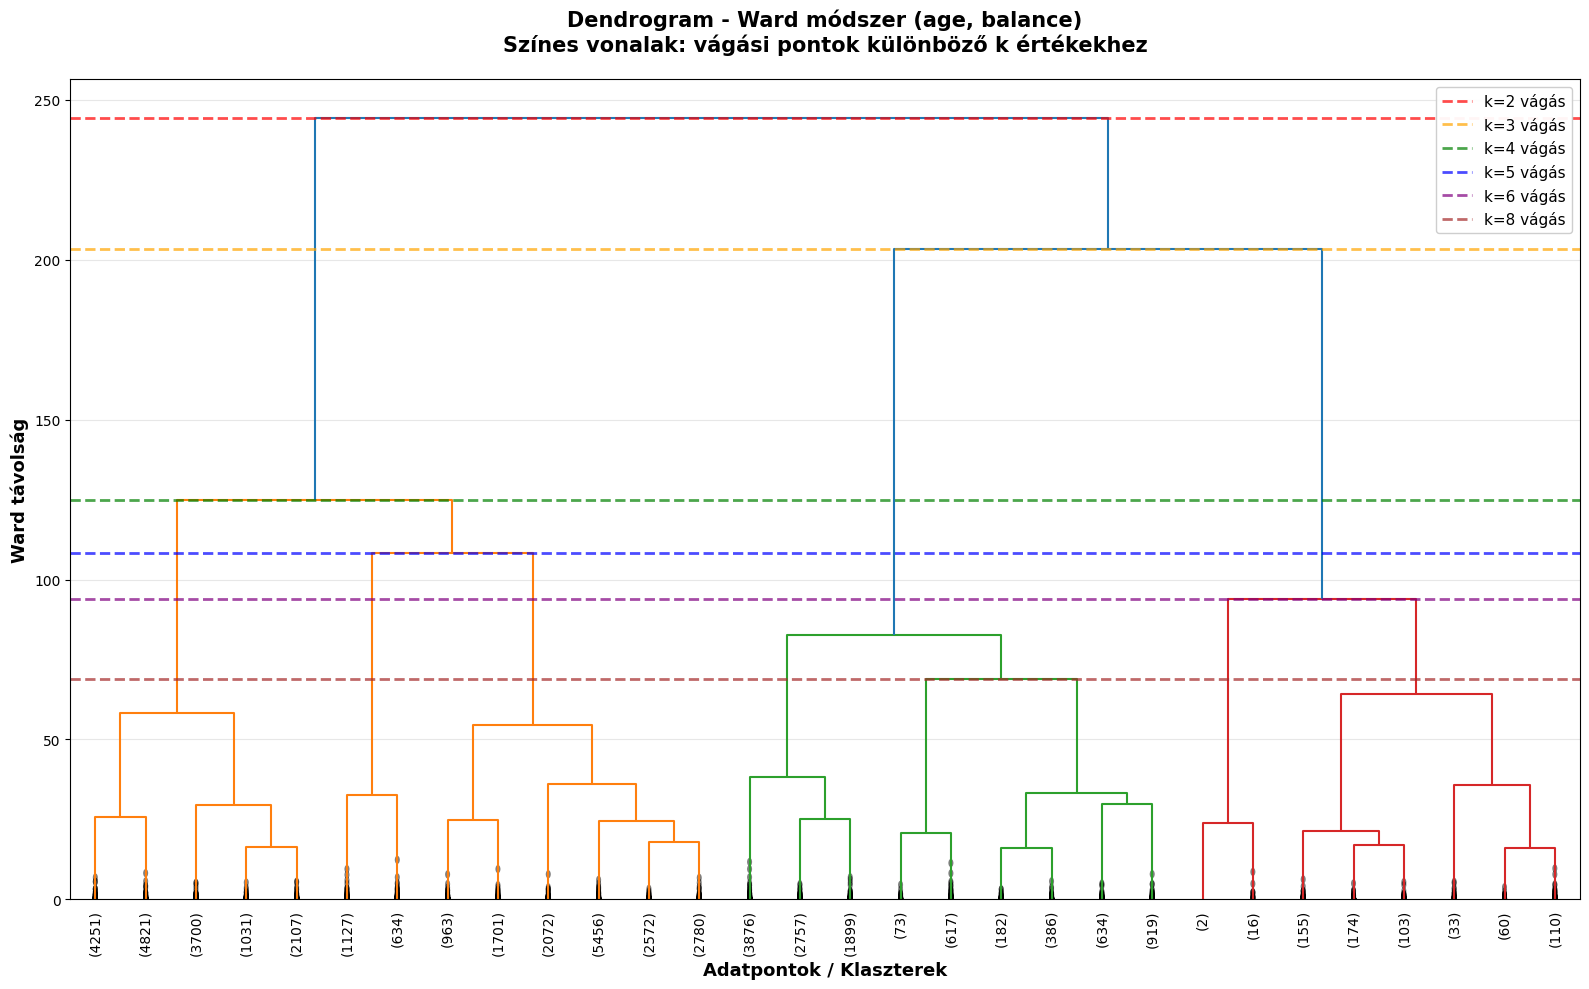

✓ Dendrogram mentve: exports_hacluster/dendrogram_ward.png


In [5]:
# Dendrogram vizualizáció
fig, ax = plt.subplots(figsize=(16, 10))

# Dendrogram - truncate mode a tisztább megjelenítéshez
dendr = dendrogram(
    Z,
    truncate_mode='lastp',  # Csak az utolsó p összevonást mutatja
    p=30,  # 30 utolsó összevonás
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)

# Vágási vonalak jelölése különböző k értékekhez
# Vágási magasságok kiszámítása
cut_heights = {
    2: Z[-1, 2],  # Utolsó összevonás távolsága
    3: Z[-2, 2],  # Utolsó előtti összevonás távolsága
    4: Z[-3, 2],
    5: Z[-4, 2],
    6: Z[-5, 2],
    8: Z[-7, 2]
}

# Színes vízszintes vonalak a vágási pontokhoz
colors_cut = ['red', 'orange', 'green', 'blue', 'purple', 'brown']
for idx, (k, height) in enumerate(cut_heights.items()):
    ax.axhline(y=height, color=colors_cut[idx], linestyle='--', 
              linewidth=2, alpha=0.7, label=f'k={k} vágás')

ax.set_xlabel('Adatpontok / Klaszterek', fontsize=13, fontweight='bold')
ax.set_ylabel('Ward távolság', fontsize=13, fontweight='bold')
ax.set_title('Dendrogram - Ward módszer (age, balance)\n' +
            'Színes vonalak: vágási pontok különböző k értékekhez',
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('exports_hacluster/dendrogram_ward.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dendrogram mentve: exports_hacluster/dendrogram_ward.png")

## 5. Hierarchikus Klaszterezés - k=2-től k=8-ig

In [6]:
# Klaszterezés különböző k értékekkel
k_range = range(2, 9)  # k=2-től k=8-ig
results = []

print("="*90)
print("HIERARCHIKUS KLASZTEREZÉS - WARD MÓDSZER")
print("k értékek: 2-től 8-ig")
print("="*90)

for k in k_range:
    # AgglomerativeClustering
    hacluster = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hacluster.fit_predict(data_scaled)
    
    # Validációs metrikák
    silhouette = silhouette_score(data_scaled, labels)
    davies_bouldin = davies_bouldin_score(data_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(data_scaled, labels)
    
    results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
        'labels': labels
    })
    
    print(f"\nk = {k}:")
    print(f"  Silhouette Score:      {silhouette:.4f}")
    print(f"  Davies-Bouldin Index:  {davies_bouldin:.4f}")
    print(f"  Calinski-Harabasz:     {calinski_harabasz:.2f}")

print("\n" + "="*90)
print("✓ Hierarchikus klaszterezés befejezve minden k értékre!")
print("="*90)

HIERARCHIKUS KLASZTEREZÉS - WARD MÓDSZER
k értékek: 2-től 8-ig

k = 2:
  Silhouette Score:      0.4908
  Davies-Bouldin Index:  0.9728
  Calinski-Harabasz:     22250.42

k = 3:
  Silhouette Score:      0.4861
  Davies-Bouldin Index:  0.7023
  Calinski-Harabasz:     28592.00

k = 4:
  Silhouette Score:      0.3436
  Davies-Bouldin Index:  0.8773
  Calinski-Harabasz:     27327.56

k = 5:
  Silhouette Score:      0.3757
  Davies-Bouldin Index:  0.8125
  Calinski-Harabasz:     27578.24

k = 6:
  Silhouette Score:      0.3770
  Davies-Bouldin Index:  0.7276
  Calinski-Harabasz:     28354.94

k = 7:
  Silhouette Score:      0.3863
  Davies-Bouldin Index:  0.8432
  Calinski-Harabasz:     29421.42


KeyboardInterrupt: 

## 6. Validációs Metrikák Exportálása

In [7]:
# Metrikák DataFrame
metrics_df = pd.DataFrame(results)[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']]
metrics_df.columns = ['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']

print("\n" + "="*90)
print("VALIDÁCIÓS METRIKÁK ÖSSZEFOGLALÁSA")
print("="*90)
print(metrics_df.to_string(index=False))
print("="*90)

# Exportálás
metrics_df.to_csv('exports_hacluster/metrics_hacluster.csv', index=False, encoding='utf-8-sig')
print("\n✓ Metrikák exportálva: exports_hacluster/metrics_hacluster.csv")


VALIDÁCIÓS METRIKÁK ÖSSZEFOGLALÁSA
 k  silhouette  davies_bouldin  calinski_harabasz
 2    0.490811        0.972784       22250.419310
 3    0.486137        0.702278       28592.000150
 4    0.343593        0.877283       27327.556153
 5    0.375667        0.812450       27578.241817
 6    0.376973        0.727591       28354.941402
 7    0.386300        0.843162       29421.422400

✓ Metrikák exportálva: exports_hacluster/metrics_hacluster.csv


## 7. Optimális k Kiválasztása

In [8]:
# Optimális k meghatározása (Silhouette Score alapján)
optimal_idx = metrics_df['silhouette'].idxmax()
optimal_k = metrics_df.loc[optimal_idx, 'k']
optimal_result = results[optimal_idx]

print("\n" + "="*90)
print("OPTIMÁLIS K KIVÁLASZTÁSA")
print("="*90)
print(f"Kiválasztási kritérium: Legmagasabb Silhouette Score")
print(f"\nOptimális k = {optimal_k}")
print(f"\nMetrikák:")
print(f"  Silhouette Score:      {optimal_result['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:  {optimal_result['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz:     {optimal_result['calinski_harabasz']:.2f}")
print("="*90)

# Optimális k összefoglaló
optimal_summary = pd.DataFrame({
    'Metrika': ['Optimális k', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Érték': [
        optimal_k,
        optimal_result['silhouette'],
        optimal_result['davies_bouldin'],
        optimal_result['calinski_harabasz']
    ],
    'Megjegyzés': [
        'Legmagasabb Silhouette alapján',
        'Magasabb = jobb',
        'Alacsonyabb = jobb',
        'Magasabb = jobb'
    ]
})

# Exportálás
optimal_summary.to_csv('exports_hacluster/optimal_k_summary.csv', index=False, encoding='utf-8-sig')
print("\n✓ Optimális k összefoglaló exportálva: exports_hacluster/optimal_k_summary.csv")


OPTIMÁLIS K KIVÁLASZTÁSA
Kiválasztási kritérium: Legmagasabb Silhouette Score

Optimális k = 2

Metrikák:
  Silhouette Score:      0.4908
  Davies-Bouldin Index:  0.9728
  Calinski-Harabasz:     22250.42

✓ Optimális k összefoglaló exportálva: exports_hacluster/optimal_k_summary.csv


## 8. Scatter Plotok Minden k-hoz (k=2-8)

In [9]:
# Scatter plotok minden k értékhez
print("\nScatter plotok generálása minden k értékhez...")

for result in results:
    k = result['k']
    labels = result['labels']
    
    # Átmeneti oszlop az ábrázoláshoz
    df_temp = df.copy()
    df_temp['cluster_temp'] = labels
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Színek
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    
    for cluster_id in range(k):
        cluster_data = df_temp[df_temp['cluster_temp'] == cluster_id]
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Cluster {cluster_id} ({len(cluster_data):,} pont)', 
                  alpha=0.6, s=30, c=[colors[cluster_id]], 
                  edgecolors='black', linewidths=0.3)
    
    # Címkék és formázás
    ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
    ax.set_title(f'Hierarchikus Klaszterezés (Ward) - k={k}\n' +
                f'Silhouette: {result["silhouette"]:.4f}, ' +
                f'Davies-Bouldin: {result["davies_bouldin"]:.4f}',
                fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Y tengely formázása
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))
    
    plt.tight_layout()
    plt.savefig(f'exports_hacluster/hacluster_k{k}_scatter.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ hacluster_k{k}_scatter.png mentve")

print("\n✓ Összes scatter plot mentve!")


Scatter plotok generálása minden k értékhez...
  ✓ hacluster_k2_scatter.png mentve
  ✓ hacluster_k3_scatter.png mentve
  ✓ hacluster_k4_scatter.png mentve
  ✓ hacluster_k5_scatter.png mentve
  ✓ hacluster_k6_scatter.png mentve
  ✓ hacluster_k7_scatter.png mentve

✓ Összes scatter plot mentve!


## 9. Metrikák Vizualizációja

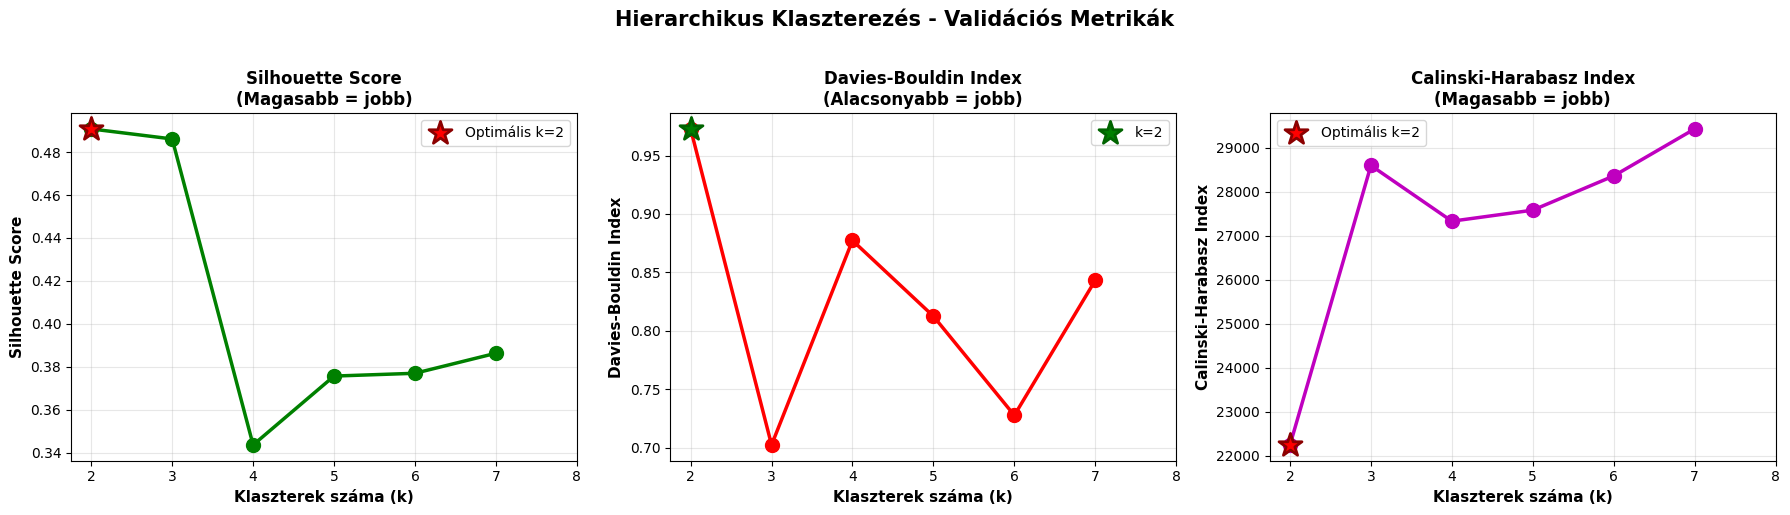

✓ Metrikák összehasonlító plot mentve: exports_hacluster/metrics_comparison.png


In [10]:
# Metrikák vizualizációja 3 külön grafikonon
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
axes[0].plot(metrics_df['k'], metrics_df['silhouette'], 'go-', linewidth=2.5, markersize=10)
axes[0].scatter([optimal_k], [optimal_result['silhouette']], 
               color='red', s=300, zorder=5, marker='*', 
               edgecolors='darkred', linewidths=2, label=f'Optimális k={optimal_k}')
axes[0].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0].set_title('Silhouette Score\n(Magasabb = jobb)', fontsize=12, fontweight='bold')
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Davies-Bouldin Index
axes[1].plot(metrics_df['k'], metrics_df['davies_bouldin'], 'ro-', linewidth=2.5, markersize=10)
axes[1].scatter([optimal_k], [optimal_result['davies_bouldin']], 
               color='green', s=300, zorder=5, marker='*', 
               edgecolors='darkgreen', linewidths=2, label=f'k={optimal_k}')
axes[1].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
axes[1].set_title('Davies-Bouldin Index\n(Alacsonyabb = jobb)', fontsize=12, fontweight='bold')
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

# Calinski-Harabasz Index
axes[2].plot(metrics_df['k'], metrics_df['calinski_harabasz'], 'mo-', linewidth=2.5, markersize=10)
axes[2].scatter([optimal_k], [optimal_result['calinski_harabasz']], 
               color='red', s=300, zorder=5, marker='*', 
               edgecolors='darkred', linewidths=2, label=f'Optimális k={optimal_k}')
axes[2].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Calinski-Harabasz Index', fontsize=11, fontweight='bold')
axes[2].set_title('Calinski-Harabasz Index\n(Magasabb = jobb)', fontsize=12, fontweight='bold')
axes[2].set_xticks(k_range)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.suptitle('Hierarchikus Klaszterezés - Validációs Metrikák', 
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exports_hacluster/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrikák összehasonlító plot mentve: exports_hacluster/metrics_comparison.png")

## 10. Klaszter Profilozás (Optimális k)

In [11]:
# Optimális címkék hozzáadása az adathalmazhoz
df['cluster_hacluster'] = optimal_result['labels']

# Klaszter profilozás
cluster_profiles = []

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster_hacluster'] == cluster_id]
    
    profile = {
        'Klaszter': cluster_id,
        'Átlag age': cluster_data['age'].mean(),
        'Szórás age': cluster_data['age'].std(),
        'Átlag balance': cluster_data['balance'].mean(),
        'Szórás balance': cluster_data['balance'].std(),
        'Elemszám (db)': len(cluster_data),
        'Elemszám (%)': len(cluster_data) / len(df) * 100
    }
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)

print("\n" + "="*100)
print(f"KLASZTER PROFILOZÁS - OPTIMÁLIS k={optimal_k}")
print("="*100)
print(profiles_df.to_string(index=False))
print("="*100)

# Exportálás
profiles_df.to_csv('exports_hacluster/cluster_profiles_hacluster.csv', 
                   index=False, encoding='utf-8-sig')
print("\n✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster.csv")


KLASZTER PROFILOZÁS - OPTIMÁLIS k=2
 Klaszter  Átlag age  Szórás age  Átlag balance  Szórás balance  Elemszám (db)  Elemszám (%)
        0  54.757503    7.180781    2469.890547     5084.133428          11996     26.533366
        1  35.944483    6.399154     962.242210     1637.313648          33215     73.466634

✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster.csv


## 11. Klaszterezett Adat Exportálása

In [12]:
# Teljes adathalmaz exportálása cluster_hacluster oszloppal
df.to_csv('exports_hacluster/clustered_data_hacluster.csv', index=False, encoding='utf-8-sig')

print("="*90)
print("KLASZTEREZETT ADAT EXPORTÁLÁSA")
print("="*90)
print(f"Fájl: clustered_data_hacluster.csv")
print(f"Sorok: {len(df):,}")
print(f"Oszlopok: {len(df.columns)} (eredeti + cluster_hacluster)")
print(f"\nKlaszter eloszlás:")
print(df['cluster_hacluster'].value_counts().sort_index())
print("="*90)

print("\n✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster.csv")

KLASZTEREZETT ADAT EXPORTÁLÁSA
Fájl: clustered_data_hacluster.csv
Sorok: 45,211
Oszlopok: 18 (eredeti + cluster_hacluster)

Klaszter eloszlás:
cluster_hacluster
0    11996
1    33215
Name: count, dtype: int64

✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster.csv


## 12. Összefoglaló és Következtetések

In [13]:
print("\n" + "="*100)
print("HIERARCHIKUS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. MÓDSZERTAN:")
print(f"   - Algoritmus: Hierarchikus (Agglomeratív) klaszterezés")
print(f"   - Linkage módszer: Ward")
print(f"   - Vizsgált klaszterszámok: k=2-től k=8-ig")
print(f"   - Használt változók: age, balance")
print(f"   - Normalizálás: StandardScaler")

print(f"\n2. OPTIMÁLIS MODELL:")
print(f"   - Optimális k: {optimal_k} (Silhouette Score alapján)")
print(f"   - Silhouette Score: {optimal_result['silhouette']:.4f}")
print(f"   - Davies-Bouldin Index: {optimal_result['davies_bouldin']:.4f}")
print(f"   - Calinski-Harabasz Index: {optimal_result['calinski_harabasz']:.2f}")

print(f"\n3. KLASZTEREK MÉRETE (k={optimal_k}):")
for _, row in profiles_df.iterrows():
    cluster_id = int(row['Klaszter'])
    count = int(row['Elemszám (db)'])
    pct = row['Elemszám (%)']
    avg_age = row['Átlag age']
    avg_balance = row['Átlag balance']
    
    print(f"   Klaszter {cluster_id}: {count:>6,} ügyfél ({pct:>5.1f}%) - "
          f"Átlag kor: {avg_age:.0f} év, Átlag egyenleg: {avg_balance:,.0f} €")

print(f"\n4. EXPORTÁLT FÁJLOK:")
print(f"   CSV fájlok:")
print(f"   - exports_hacluster/metrics_hacluster.csv - Validációs metrikák (k=2-8)")
print(f"   - exports_hacluster/optimal_k_summary.csv - Optimális k összefoglaló")
print(f"   - exports_hacluster/cluster_profiles_hacluster.csv - Klaszter profilok")
print(f"   - exports_hacluster/clustered_data_hacluster.csv - Teljes adathalmaz címkékkel")
print(f"   \n   PNG ábrák:")
print(f"   - exports_hacluster/dendrogram_ward.png - Dendrogram vágási pontokkal")
print(f"   - exports_hacluster/metrics_comparison.png - Metrikák összehasonlítása")
print(f"   - exports_hacluster/hacluster_k{{k}}_scatter.png - 7 scatter plot (k=2-8)")

print(f"\n5. KÖVETKEZTETÉSEK:")
print(f"   A hierarchikus klaszterezés (Ward módszer) sikeresen")
print(f"   azonosította az optimális {optimal_k} klasztert az adathalmazban.")
print(f"   ")
print(f"   A dendrogram alapján jól látható a hierarchikus struktúra,")
print(f"   amely lehetővé teszi különböző granularitású klaszterezések")
print(f"   vizsgálatát a vágási pont változtatásával.")
print(f"   ")
print(f"   A Ward módszer minimalizálja a klasztereken belüli varianciát,")
print(f"   így kompakt, jól elkülöníthető klasztereket hoz létre.")

print("\n" + "="*100)
print("✓ HIERARCHIKUS KLASZTEREZÉS SIKERESEN BEFEJEZVE!")
print("="*100)


HIERARCHIKUS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ

1. MÓDSZERTAN:
   - Algoritmus: Hierarchikus (Agglomeratív) klaszterezés
   - Linkage módszer: Ward
   - Vizsgált klaszterszámok: k=2-től k=8-ig
   - Használt változók: age, balance
   - Normalizálás: StandardScaler

2. OPTIMÁLIS MODELL:
   - Optimális k: 2 (Silhouette Score alapján)
   - Silhouette Score: 0.4908
   - Davies-Bouldin Index: 0.9728
   - Calinski-Harabasz Index: 22250.42

3. KLASZTEREK MÉRETE (k=2):
   Klaszter 0: 11,996 ügyfél ( 26.5%) - Átlag kor: 55 év, Átlag egyenleg: 2,470 €
   Klaszter 1: 33,215 ügyfél ( 73.5%) - Átlag kor: 36 év, Átlag egyenleg: 962 €

4. EXPORTÁLT FÁJLOK:
   CSV fájlok:
   - exports_hacluster/metrics_hacluster.csv - Validációs metrikák (k=2-8)
   - exports_hacluster/optimal_k_summary.csv - Optimális k összefoglaló
   - exports_hacluster/cluster_profiles_hacluster.csv - Klaszter profilok
   - exports_hacluster/clustered_data_hacluster.csv - Teljes adathalmaz címkékkel
   
   PNG ábrák:
   - exports_h